In [7]:
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/processed_data.zip" .
!unzip processed_data.zip

Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/processed_data.zip': No such file or directory
Archive:  processed_data.zip
replace processed_data/Facial_Recognition_Test/Jennifer Lawrence/Jennifer_Lawrence_0003.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: processed_data/Facial_Recognition_Test/Jennifer Lawrence/Jennifer_Lawrence_0003.jpg  
  inflating: processed_data/Facial_Recognition_Test/Jennifer Lawrence/Jennifer_Lawrence_0002.jpg  
  inflating: processed_data/Facial_Recognition_Test/Jennifer Lawrence/Jennifer_Lawrence_0001.jpg  
  inflating: processed_data/Facial_Recognition_Test/Angelina Jolie/Angelina_Jolie_0001.jpg  
  inflating: processed_data/Facial_Recognition_Test/Angelina Jolie/Angelina_Jolie_0002.jpg  
  inflating: processed_data/Facial_Recognition_Test/Tom Hanks/Tom_Hanks_0001.jpg  
  inflating: processed_data/Facial_Recognition_Test/Tom Hanks/Tom_Hanks_0002.jpg  
 extracting: processed_data/Facial_Recognition_Test/test.txt  
  inflating: 

In [1]:
!pip install opencv-python dlib matplotlib tqdm face_recognition requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=8338648b5a39578070aa94c83e8b473b5724a336d5de74d2f1fe224ba26fa32a
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


Model downloaded and extracted.
Dataset Path: processed_data
Total images: 56


100%|██████████| 56/56 [00:02<00:00, 19.78it/s]


Train: 29
Val: 7
Test: 9

Saved: face_embeddings.npz

Failed images: 11
('processed_data/Facial_Recognition_Val/Jennifer Lawrence/082_2251d7b7.jpg', 'no face')
('processed_data/Facial_Recognition_Val/Tom Hanks/Tom_Hanks_0002.jpg', 'no face')
('processed_data/Facial_Recognition_Val/Will Smith/Will_Smith_0003.jpg', 'no face')
('processed_data/Facial_Recognition_Val/Will Smith/Will_Smith_0001.jpg', 'embedding failed')
('processed_data/Facial_Recognition_Val/Will Smith/Will_Smith_0002.jpg', 'no face')
('processed_data/Facial_Recognition_Test/Will Smith/Will_Smith_0002.jpg', 'no face')
('processed_data/Facial_Recognition_Test/Angelina Jolie/Angelina_Jolie_0002.jpg', 'no face')
('processed_data/Facial_Recognition_Train/Jennifer Lawrence/Jennifer_Lawrence_0001.jpg', 'no face')
('processed_data/Facial_Recognition_Train/Jennifer Lawrence/Jennifer_Lawrence_0003.jpg', 'no face')
('processed_data/Facial_Recognition_Train/Tom Hanks/Tom_Hanks_0001.jpg', 'no face')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Sample Pipeline Results:


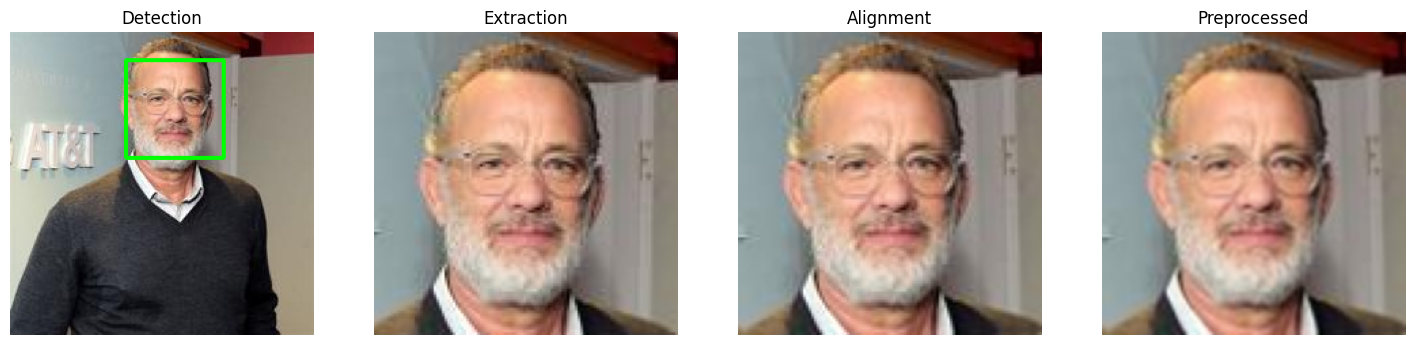

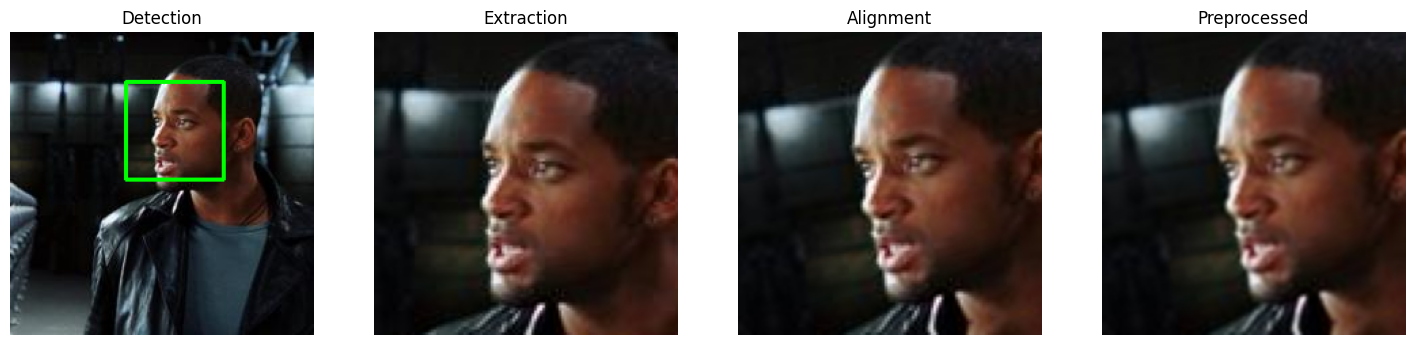

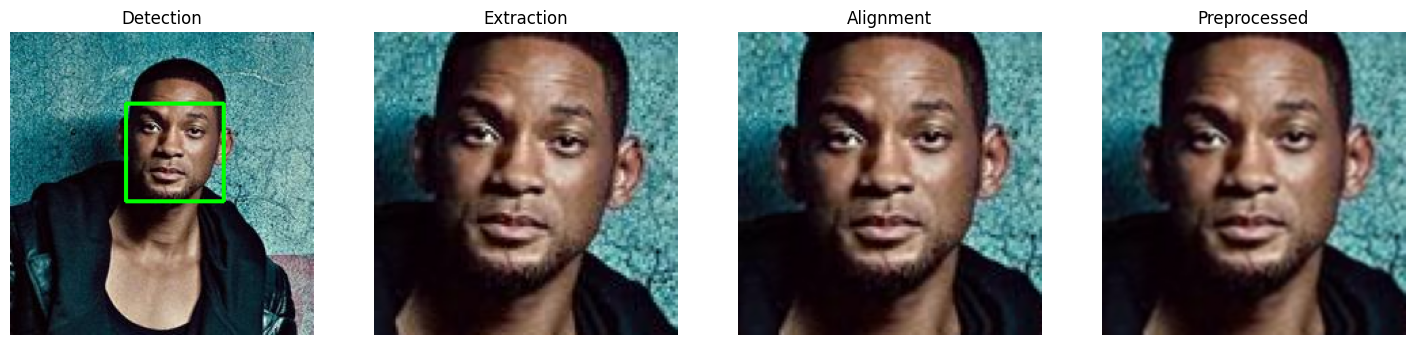

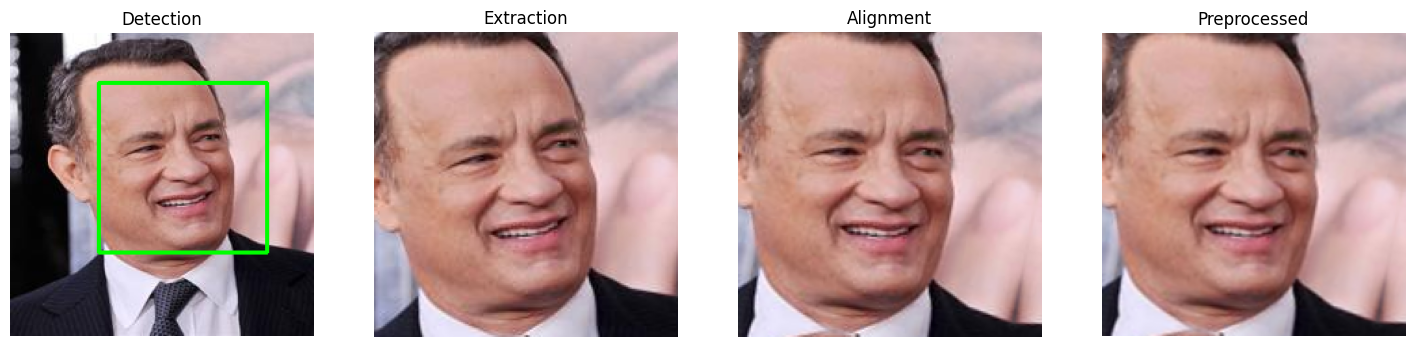

In [10]:
import urllib.request
import os
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import face_recognition
import shutil
import random
import requests
from zipfile import ZipFile

url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
file_name = "shape_predictor_68_face_landmarks.dat.bz2"

if not os.path.exists("shape_predictor_68_face_landmarks.dat"):
    print("Downloading landmark model...")

    urllib.request.urlretrieve(url, file_name)

    import bz2

    with bz2.BZ2File(file_name) as fr, open("shape_predictor_68_face_landmarks.dat", "wb") as fw:
        fw.write(fr.read())

    print("Model downloaded and extracted.")

random.seed(42)
np.random.seed(42)


input_root = "processed_data"
output_dir = "preprocess_aligned"
embedding_file = "face_embeddings.npz"

IMG_SIZE = 224
NUM_SAMPLES = 5

# Load Set

print("Dataset Path:", input_root)

# Models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Face Detection
def detect_faces(img):
    return detector(img)

# Face Extraction
def extract_face(img, rect, pad=20):
    x1 = max(rect.left() - pad, 0)
    y1 = max(rect.top() - pad, 0)
    x2 = min(rect.right() + pad, img.shape[1])
    y2 = min(rect.bottom() + pad, img.shape[0])

    face = img[y1:y2, x1:x2]
    return face if face.size != 0 else None

# Face Alignment
def align_face(face_img):
    try:
        gray = cv2.cvtColor(face_img, cv2.COLOR_RGB2GRAY)
        rect = dlib.rectangle(0, 0, face_img.shape[1], face_img.shape[0])
        landmarks = predictor(gray, rect)

        left_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(36,42)], axis=0)
        right_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(42,48)], axis=0)

        dx = right_eye[0] - left_eye[0]
        dy = right_eye[1] - left_eye[1]
        angle = np.degrees(np.arctan2(dy, dx))

        eyes_center = ((left_eye[0] + right_eye[0]) / 2,
                       (left_eye[1] + right_eye[1]) / 2)

        M = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)

        aligned = cv2.warpAffine(
            face_img,
            M,
            (face_img.shape[1], face_img.shape[0]),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REFLECT
        )

        return aligned

    except:
        return None

# Preprocessing (RGB + 224x224)
def preprocess(img):
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    return img

# Save Image
def save_image(img, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.imsave(path, (img * 255).astype(np.uint8))

# Embeddings
def get_embedding(img):
    img_uint8 = (img * 255).astype(np.uint8)
    enc = face_recognition.face_encodings(img_uint8)
    return enc[0] if len(enc) > 0 else None

# Load All Images
image_paths = []
for root, dirs, files in os.walk(input_root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, f))

print("Total images:", len(image_paths))

# Storage
embeddings = {
    "train_embeddings": [], "train_labels": [],
    "val_embeddings": [], "val_labels": [],
    "test_embeddings": [], "test_labels": []
}

train_paths, val_paths, test_paths = [], [], []

failed = []

# Main Pipeline
for img_path in tqdm(image_paths):

    img = cv2.imread(img_path)
    if img is None:
        failed.append((img_path, "read failed"))
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        failed.append((img_path, "no face"))
        continue

    face = extract_face(img_rgb, faces[0])
    if face is None:
        failed.append((img_path, "crop failed"))
        continue

    aligned = align_face(face)
    if aligned is None:
        failed.append((img_path, "alignment failed"))
        continue

    processed = preprocess(aligned)
    if processed is None:
        failed.append((img_path, "preprocess failed"))
        continue

    # Save Image
    rel_path = img_path.replace(input_root, "").lstrip("/")
    save_image(processed, os.path.join(output_dir, rel_path))

    # Embedding
    emb = get_embedding(processed)
    if emb is None:
        failed.append((img_path, "embedding failed"))
        continue

    label = os.path.basename(os.path.dirname(img_path))

    # Dataset Split Detection
    path_lower = img_path.replace("\\", "/").lower()

    if "train" in path_lower:
        embeddings["train_embeddings"].append(emb)
        embeddings["train_labels"].append(label)
        train_paths.append(img_path)
    elif "val" in path_lower:
        embeddings["val_embeddings"].append(emb)
        embeddings["val_labels"].append(label)
        val_paths.append(img_path)
    elif "test" in path_lower:
        embeddings["test_embeddings"].append(emb)
        embeddings["test_labels"].append(label)
        test_paths.append(img_path)

# Debug Check
print("\nTrain:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

# Prevent empty dataset crash
assert len(train_paths) > 0, "Train set empty"
assert len(val_paths) > 0, "Val set empty"
assert len(test_paths) > 0, "Test set empty"

# Save Embeddings + Paths
np.savez(
    embedding_file,

    train_embeddings=np.array(embeddings["train_embeddings"]),
    train_labels=np.array(embeddings["train_labels"]),
    train_paths=np.array(train_paths),

    val_embeddings=np.array(embeddings["val_embeddings"]),
    val_labels=np.array(embeddings["val_labels"]),
    val_paths=np.array(val_paths),

    test_embeddings=np.array(embeddings["test_embeddings"]),
    test_labels=np.array(embeddings["test_labels"]),
    test_paths=np.array(test_paths)
)

print("\nSaved:", embedding_file)

# Failure Report
print("\nFailed images:", len(failed))
for f in failed[:10]:
    print(f)

# Zip Output
shutil.make_archive(output_dir, "zip", output_dir)

from google.colab import files
files.download(output_dir + ".zip")
files.download(embedding_file)


# Visualization
def visualize_pipeline(img_path):

    img = cv2.imread(img_path)
    if img is None:
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        return

    rect = faces[0]

    # Original with box
    img_box = img_rgb.copy()
    cv2.rectangle(
        img_box,
        (rect.left(), rect.top()),
        (rect.right(), rect.bottom()),
        (0,255,0), 2
    )

    face = extract_face(img_rgb, rect)
    aligned = align_face(face)
    processed = preprocess(aligned)

    fig, ax = plt.subplots(1,4, figsize=(18,5))

    ax[0].imshow(img_box)
    ax[0].set_title("Detection")
    ax[0].axis("off")

    ax[1].imshow(face)
    ax[1].set_title("Extraction")
    ax[1].axis("off")

    ax[2].imshow(aligned)
    ax[2].set_title("Alignment")
    ax[2].axis("off")

    ax[3].imshow(processed)
    ax[3].set_title("Preprocessed")
    ax[3].axis("off")

    plt.show()

# Show 5 samples
print("\nSample Pipeline Results:")
samples = random.sample(image_paths, min(5, len(image_paths)))

for p in samples:
    visualize_pipeline(p)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [6]:
!ls -1h

processed_data
processed_data.zip
sample_data


In [9]:
!ls processed_data

Facial_Recognition_Test  Facial_Recognition_Train  Facial_Recognition_Val
